<a href="https://colab.research.google.com/github/ABRARFARHANN/MTech---Mini-Project-/blob/main/MP_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import files
 uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [ ]:
!pip install -q albumentations opencv-python-headless


In [ ]:
import zipfile

with zipfile.ZipFile("archive (5).zip", 'r') as zip_ref:
    zip_ref.extractall("bt_dataset")

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [ ]:
 import os
 os.listdir("bt_dataset")

['Testing', 'Training']

In [ ]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import albumentations as A
import seaborn as sns

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
from tensorflow.keras import backend as K
from tensorflow.keras.utils import Sequence


def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1. - K.epsilon())
    cross_entropy = -y_true * tf.math.log(y_pred)
    weight = alpha * tf.pow(1 - y_pred, gamma)
    loss = weight * cross_entropy
    return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

In [ ]:
transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0), p=1.0),  # ✅ FIXED: use size tuple
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.7)
])


In [ ]:
from sklearn.utils import shuffle

def load_image_paths_and_labels(data_dir, class_labels):
    image_paths = []
    labels = []

    for label in class_labels:
        label_dir = os.path.join(data_dir, label)
        for img_file in os.listdir(label_dir):
            if img_file.lower().endswith((".png", ".jpg", ".jpeg")):
                image_paths.append(os.path.join(label_dir, img_file))
                labels.append(class_labels.index(label))

    return shuffle(image_paths, labels)

# Dataset paths
train_dir = "bt_dataset/Training"
test_dir = "bt_dataset/Testing"

# Class names
class_labels = sorted(os.listdir(train_dir))

# Load paths and labels
train_paths, train_labels = load_image_paths_and_labels(train_dir, class_labels)
test_paths, test_labels = load_image_paths_and_labels(test_dir, class_labels)

# Split train/val manually
split_idx = int(len(train_paths) * 0.8)
train_data = AlbumentationsDataGenerator(train_paths[:split_idx], train_labels[:split_idx], 32, transform)
val_data   = AlbumentationsDataGenerator(train_paths[split_idx:], train_labels[split_idx:], 32, transform)
test_data  = AlbumentationsDataGenerator(test_paths, test_labels, 1, transform, shuffle=False)


In [ ]:
class AlbumentationsDataGenerator(Sequence):
    def __init__(self, image_paths, labels, batch_size, augmentations, num_classes=4, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augmentations
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_paths = self.image_paths[index * self.batch_size:(index + 1) * self.batch_size]
        batch_labels = self.labels[index * self.batch_size:(index + 1) * self.batch_size]

        batch_images = []
        for img_path in batch_paths:
            img = np.array(Image.open(img_path).convert("RGB"))
            augmented = self.augment(image=img)
            batch_images.append(augmented["image"] / 255.0)

        batch_images = np.array(batch_images)
        batch_labels = to_categorical(batch_labels, num_classes=self.num_classes)
        return batch_images, batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            combined = list(zip(self.image_paths, self.labels))
            np.random.shuffle(combined)
            self.image_paths, self.labels = zip(*combined)


In [ ]:
from sklearn.utils import shuffle

train_dir = "bt_dataset/Training"
test_dir = "bt_dataset/Testing"
class_labels = sorted(os.listdir(train_dir))

def load_image_paths_and_labels(data_dir, class_labels):
    image_paths = []
    labels = []
    for label in class_labels:
        label_dir = os.path.join(data_dir, label)
        for img_file in os.listdir(label_dir):
            if img_file.lower().endswith((".png", ".jpg", ".jpeg")):
                image_paths.append(os.path.join(label_dir, img_file))
                labels.append(class_labels.index(label))
    return shuffle(image_paths, labels)

train_paths, train_labels = load_image_paths_and_labels(train_dir, class_labels)
test_paths, test_labels = load_image_paths_and_labels(test_dir, class_labels)

split_idx = int(len(train_paths) * 0.8)
train_data = AlbumentationsDataGenerator(train_paths[:split_idx], train_labels[:split_idx], 32, transform)
val_data = AlbumentationsDataGenerator(train_paths[split_idx:], train_labels[split_idx:], 32, transform)
test_data = AlbumentationsDataGenerator(test_paths, test_labels, 1, transform, shuffle=False)

In [ ]:
base_model = DenseNet201(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# Unfreeze the last 50 layers for fine-tuning
for layer in base_model.layers[:-50]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(len(class_labels), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=focal_loss, metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,823,492 (71.81 MB)

 Trainable params: 2,388,164 (9.11 MB)

 Non-trainable params: 16,435,328 (62.70 MB)

In [ ]:
from PIL import Image

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.5043 - loss: 0.2914
Epoch 1: val_loss improved from inf to 0.05227, saving model to best_model.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 158s 703ms/step - accuracy: 0.5051 - loss: 0.2908 - val_accuracy: 0.8390 - val_loss: 0.0523 - learning_rate: 1.0000e-04
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7660 - loss: 0.1088
Epoch 2: val_loss improved from 0.05227 to 0.04416, saving model to best_model.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 296ms/step - accuracy: 0.7661 - loss: 0.1087 - val_accuracy: 0.8845 - val_loss: 0.0442 - learning_rate: 1.0000e-04
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8069 - loss: 0.0877
Epoch 3: val_loss improved from 0.04416 to 0.03413, saving model to best_model.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 289ms/step - accuracy: 0.8070 - loss: 0.0877 - val_accuracy: 0.9099 - val_loss: 0.0341 - learning_rate: 1.0000e-04
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8328 - loss: 0.0685
Epoch 4: val_loss improved from 0.03413 to 0.02721, saving model to best_model.h5


...

143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 294ms/step - accuracy: 0.9305 - loss: 0.0274 - val_accuracy: 0.9563 - val_loss: 0.0128 - learning_rate: 1.0000e-04
Epoch 14/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9349 - loss: 0.0229
Epoch 14: val_loss did not improve from 0.01285
143/143 ━━━━━━━━━━━━━━━━━━━━ 37s 259ms/step - accuracy: 0.9349 - loss: 0.0229 - val_accuracy: 0.9519 - val_loss: 0.0168 - learning_rate: 1.0000e-04
Epoch 15/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9319 - loss: 0.0224
Epoch 15: val_loss did not improve from 0.01285
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 281ms/step - accuracy: 0.9320 - loss: 0.0224 - val_accuracy: 0.9519 - val_loss: 0.0192 - learning_rate: 1.0000e-04
Epoch 16/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9462 - loss: 0.0179
Epoch 16: val_loss did not improve from 0.01285

Epoch 16: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 276ms/step - accuracy: 0.9462 - l

143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - accuracy: 0.9608 - loss: 0.0104 - val_accuracy: 0.9624 - val_loss: 0.0122 - learning_rate: 3.0000e-05
Epoch 20/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9462 - loss: 0.0202
Epoch 20: val_loss did not improve from 0.01218
143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 274ms/step - accuracy: 0.9462 - loss: 0.0202 - val_accuracy: 0.9589 - val_loss: 0.0145 - learning_rate: 3.0000e-05
Epoch 21/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9585 - loss: 0.0118
Epoch 21: val_loss did not improve from 0.01218
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 285ms/step - accuracy: 0.9585 - loss: 0.0118 - val_accuracy: 0.9633 - val_loss: 0.0157 - learning_rate: 3.0000e-05
Epoch 22/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9548 - loss: 0.0154
Epoch 22: val_loss did not improve from 0.01218

Epoch 22: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.9548 - lo

143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 291ms/step - accuracy: 0.9599 - loss: 0.0150 - val_accuracy: 0.9659 - val_loss: 0.0122 - learning_rate: 9.0000e-06
Epoch 24/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9704 - loss: 0.0080
Epoch 24: val_loss improved from 0.01218 to 0.01049, saving model to best_model.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step - accuracy: 0.9703 - loss: 0.0081 - val_accuracy: 0.9694 - val_loss: 0.0105 - learning_rate: 9.0000e-06
Epoch 25/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9645 - loss: 0.0118
Epoch 25: val_loss did not improve from 0.01049
143/143 ━━━━━━━━━━━━━━━━━━━━ 76s 270ms/step - accuracy: 0.9645 - loss: 0.0118 - val_accuracy: 0.9685 - val_loss: 0.0125 - learning_rate: 9.0000e-06
Epoch 26/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9560 - loss: 0.0136
Epoch 26: val_loss did not improve from 0.01049
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.9561 - loss: 0.0136 - val_accuracy: 0.9738 - val_loss: 0.0120 - learning_rate: 9.0000e-06
Epoch 27/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9626 - loss: 0.0146
Epoch 27: val_loss improved from 0.01049 to 0.00877, saving model to best_model.h5


143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 295ms/step - accuracy: 0.9626 - loss: 0.0146 - val_accuracy: 0.9711 - val_loss: 0.0088 - learning_rate: 9.0000e-06
Epoch 28/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9708 - loss: 0.0086
Epoch 28: val_loss did not improve from 0.00877
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 277ms/step - accuracy: 0.9707 - loss: 0.0086 - val_accuracy: 0.9676 - val_loss: 0.0152 - learning_rate: 9.0000e-06
Epoch 29/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.9666 - loss: 0.0100
Epoch 29: val_loss did not improve from 0.00877
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 268ms/step - accuracy: 0.9665 - loss: 0.0100 - val_accuracy: 0.9694 - val_loss: 0.0117 - learning_rate: 9.0000e-06
Epoch 30/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9657 - loss: 0.0105
Epoch 30: val_loss did not improve from 0.00877

Epoch 30: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 276ms/step - accuracy: 0.9657 - l

In [ ]:
model = tf.keras.models.load_model('best_model.h5', custom_objects={'focal_loss': focal_loss})
y_true = test_labels
y_pred = model.predict(test_data, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 51s 25ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.94      0.97       300
  meningioma       0.94      0.97      0.95       306
     notumor       0.99      1.00      0.99       405
   pituitary       0.98      0.99      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.97      0.97      1311
weighted avg       0.98      0.98      0.98      1311



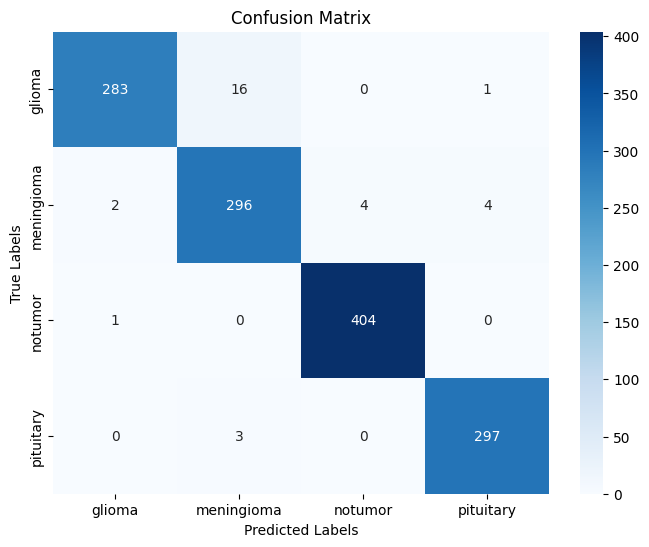

In [ ]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
image_path = "/content/bt_dataset/Testing/notumor/Te-noTr_0004.jpg"


In [ ]:
def detect_and_display(image_path, model, class_labels):
    from PIL import Image
    import numpy as np
    import matplotlib.pyplot as plt

    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = class_labels[np.argmax(pred)]

    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


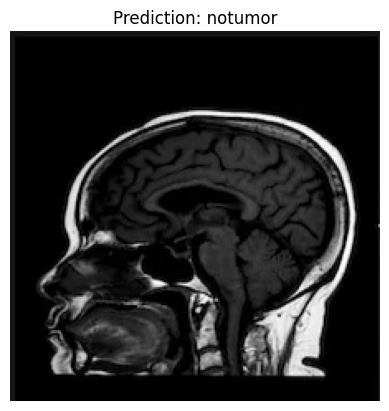

In [ ]:
image_path = "/content/bt_dataset/Testing/notumor/Te-noTr_0004.jpg"
detect_and_display(image_path, model, class_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


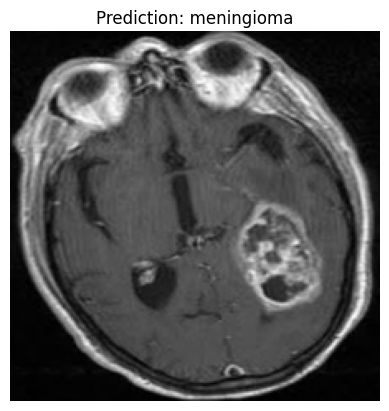

In [ ]:
image_path = "/content/bt_dataset/Testing/meningioma/Te-meTr_0001.jpg"
detect_and_display(image_path, model, class_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


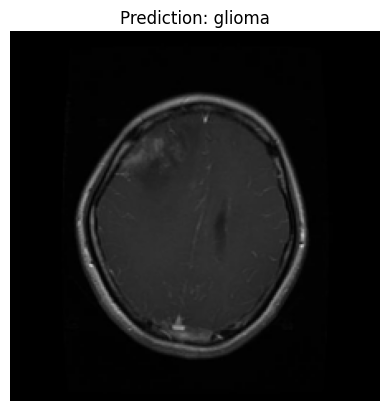

In [ ]:
image_path = "/content/bt_dataset/Testing/glioma/Te-glTr_0002.jpg"
detect_and_display(image_path, model, class_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


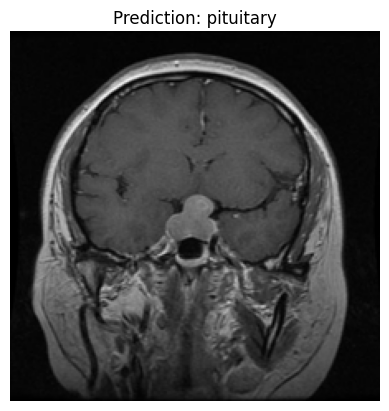

In [ ]:
image_path = "/content/bt_dataset/Testing/pituitary/Te-piTr_0001.jpg"
detect_and_display(image_path, model, class_labels)
